# Comparación de Modelos y Optimización de Pipeline en el Dataset Titanic

## Trabajo de Tutoría — Introducción a Machine Learning

Este proyecto tiene como objetivo construir un flujo completo de Machine Learning para predecir la supervivencia de pasajeros del Titanic. El trabajo incluye preprocesamiento, feature engineering, construcción de pipelines, comparación de modelos de clasificación, búsqueda de hiperparámetros, evaluación con métricas completas y análisis de overfitting.

## Distribución del trabajo

| Integrante | Tareas realizadas |
|---|---|
| Kira Carrasco | Limpieza inicial, exploración del dataset y revisión de valores faltantes |
| Andres Ledesma | Feature engineering y justificación de nuevas variables |
| Carlos Yepez | Construcción del Pipeline, preprocesamiento y entrenamiento de modelos |
| Alfredo Villavicencio | Búsqueda de hiperparámetros, evaluación, gráficos, análisis de overfitting e informe |

## Estructura del notebook

1. Importación de librerías
2. Carga del dataset Titanic
3. Exploración inicial de los datos
4. Separación entre variables predictoras y variable objetivo
5. División entre entrenamiento y prueba
6. Feature engineering
7. Construcción del Pipeline de preprocesamiento
8. Entrenamiento de modelos
9. Búsqueda de hiperparámetros
10. Evaluación comparativa
11. Matriz de confusión del mejor modelo
12. Curvas ROC de todos los modelos
13. Análisis de overfitting
14. Importancia de variables
15. Conclusiones finales

In [1]:
# Importación de librerías principales

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## 2. Carga del dataset Titanic

En esta sección se carga el dataset Titanic usando la librería Seaborn. El objetivo inicial es comprender la estructura de los datos antes de realizar cualquier transformación o entrenamiento de modelos.

El problema consiste en predecir la variable `survived`, que indica si un pasajero sobrevivió o no al hundimiento del Titanic. Esta es una tarea de clasificación binaria, porque la variable objetivo solo puede tomar dos valores: 0 para no sobrevivió y 1 para sobrevivió.

In [2]:
# Carga del dataset Titanic desde Seaborn

df = sns.load_dataset("titanic")

# Visualización de las primeras filas
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Exploración inicial de los datos

Antes de construir el modelo, se revisan las dimensiones del dataset, los tipos de variables, los valores faltantes y la distribución de la variable objetivo. Esta exploración permite identificar qué columnas pueden ser útiles, cuáles necesitan tratamiento especial y cuáles podrían generar problemas de data leakage.

In [3]:
# Dimensiones del dataset

df.shape

(891, 15)

In [4]:
# Nombres de las columnas

df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
# Cantidad de valores faltantes por columna

df.isnull().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


In [7]:
# Estadísticas descriptivas de variables numéricas

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Estadísticas descriptivas incluyendo variables categóricas

df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Revisión de la variable objetivo

La variable objetivo del proyecto es `survived`. Esta variable indica si el pasajero sobrevivió al hundimiento del Titanic. El valor 1 representa que el pasajero sobrevivió y el valor 0 representa que no sobrevivió.

Es importante revisar su distribución porque permite saber si las clases están balanceadas o si existe una diferencia importante entre sobrevivientes y no sobrevivientes.

In [9]:
# Conteo absoluto de la variable objetivo

df["survived"].value_counts()

,count
survived,
0,549
1,342


In [10]:
# Conteo porcentual de la variable objetivo

df["survived"].value_counts(normalize=True)

,proportion
survived,
0,0.616162
1,0.383838


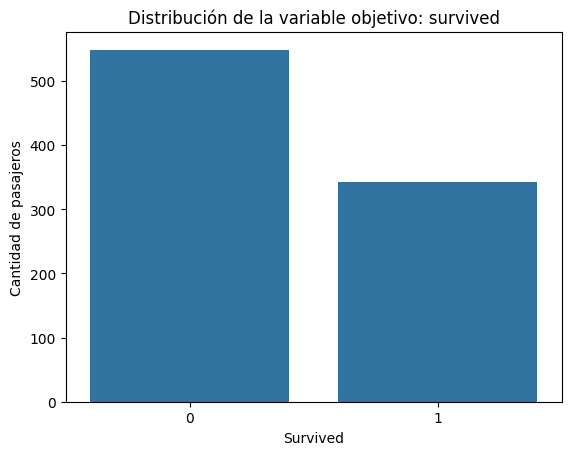

In [11]:
# Gráfico de distribución de la variable objetivo

sns.countplot(data=df, x="survived")
plt.title("Distribución de la variable objetivo: survived")
plt.xlabel("Survived")
plt.ylabel("Cantidad de pasajeros")
plt.show()

## 5. Separación de variables predictoras y variable objetivo

En esta sección se separa la variable objetivo `survived` de las variables predictoras. La variable `survived` será lo que el modelo intentará predecir.

También se elimina la variable `alive`, porque contiene la misma información que `survived` expresada como texto. Usarla como variable predictora causaría data leakage, ya que el modelo tendría acceso indirecto a la respuesta real.

In [12]:
# Separación entre variables predictoras y variable objetivo

X = df.drop(columns=["survived", "alive"])
y = df["survived"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (891, 13)
Dimensiones de y: (891,)


## 6. División entre entrenamiento y prueba

El dataset se divide en dos partes: un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se usará para ajustar los modelos, mientras que el conjunto de prueba se reservará para evaluar el rendimiento final con datos no vistos durante el entrenamiento.

Se usa `stratify=y` para mantener una proporción similar de sobrevivientes y no sobrevivientes en ambos conjuntos.

In [13]:
# División del dataset en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 13)
X_test: (179, 13)
y_train: (712,)
y_test: (179,)


In [14]:
# Comparación de la distribución de la variable objetivo

print("Distribución en dataset completo:")
print(y.value_counts(normalize=True))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución en dataset completo:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Distribución en entrenamiento:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Distribución en prueba:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## 7. Feature engineering

En esta sección se crean nuevas variables a partir de las columnas originales del dataset Titanic. El objetivo del feature engineering es generar información adicional que pueda ayudar a los modelos a distinguir mejor entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron.

Las variables creadas serán incorporadas dentro de un transformador personalizado para que puedan formar parte del Pipeline de scikit-learn. Esto permite aplicar las mismas transformaciones durante entrenamiento, validación y prueba, reduciendo el riesgo de data leakage.

### Variables creadas

1. `FamilySize`: representa el tamaño del grupo familiar del pasajero. Se calcula como `sibsp + parch + 1`. Puede aportar información porque viajar con familiares pudo influir en la posibilidad de recibir ayuda o en las decisiones durante la evacuación.

2. `IsAlone_custom`: identifica si el pasajero viajaba solo. Toma el valor 1 si `FamilySize` es igual a 1, y 0 en caso contrario. Puede ser útil porque un pasajero solo pudo enfrentar la emergencia de forma distinta a un pasajero acompañado.

3. `Fare_per_person`: aproxima cuánto pagó cada persona dentro del grupo familiar. Se calcula dividiendo `fare` entre `FamilySize`. Puede ser una mejor señal del nivel socioeconómico individual que la tarifa total.

4. `CabinKnown`: indica si el pasajero tenía información de cabina registrada. Puede capturar diferencias relacionadas con clase social, ubicación dentro del barco o calidad del registro.

5. `AgeClassInteraction`: combina edad y clase del pasajero. Puede aportar información porque el efecto de la edad sobre la supervivencia pudo no ser igual para todas las clases.

In [15]:
# Importación necesaria para crear un transformador personalizado

from sklearn.base import BaseEstimator, TransformerMixin

In [16]:
# Transformador personalizado para feature engineering

class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Tamaño del grupo familiar
        X["FamilySize"] = X["sibsp"] + X["parch"] + 1

        # Indicador de pasajero que viaja solo
        X["IsAlone_custom"] = (X["FamilySize"] == 1).astype(int)

        # Tarifa pagada por persona
        X["Fare_per_person"] = X["fare"] / X["FamilySize"]

        # Indicador de si la cabina está registrada
        X["CabinKnown"] = X["deck"].notna().astype(int)

        # Interacción entre edad y clase
        X["AgeClassInteraction"] = X["age"] * X["pclass"]

        return X

In [17]:
# Prueba del transformador personalizado sobre el conjunto de entrenamiento

feature_engineer = TitanicFeatureEngineer()
X_train_fe_preview = feature_engineer.fit_transform(X_train)

X_train_fe_preview[
    [
        "sibsp",
        "parch",
        "fare",
        "deck",
        "age",
        "pclass",
        "FamilySize",
        "IsAlone_custom",
        "Fare_per_person",
        "CabinKnown",
        "AgeClassInteraction"
    ]
].head()

,sibsp,parch,fare,deck,age,pclass,FamilySize,IsAlone_custom,Fare_per_person,CabinKnown,AgeClassInteraction
692,0,0,56.4958,NaN,NaN,3,1,1,56.4958,0,NaN
481,0,0,0.0000,NaN,NaN,2,1,1,0.0000,0,NaN
527,0,0,221.7792,C,NaN,1,1,1,221.7792,1,NaN
855,0,1,9.3500,NaN,18.0,3,2,0,4.6750,0,54.0
801,1,1,26.2500,NaN,31.0,2,3,0,8.7500,0,62.0


## 8. Definición de variables numéricas y categóricas

Después del feature engineering, se seleccionan las variables que serán usadas por los modelos. No es obligatorio usar todas las columnas originales, especialmente si algunas son redundantes o pueden generar ruido.

Las variables numéricas serán imputadas y escaladas. Las variables categóricas serán imputadas y codificadas mediante OneHotEncoder.

In [18]:
# Definición de columnas numéricas y categóricas

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "FamilySize",
    "IsAlone_custom",
    "Fare_per_person",
    "CabinKnown",
    "AgeClassInteraction"
]

categorical_features = [
    "sex",
    "embarked",
    "who"
]

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone_custom', 'Fare_per_person', 'CabinKnown', 'AgeClassInteraction']

Variables categóricas:
['sex', 'embarked', 'who']


## 9. Construcción del preprocesamiento

El preprocesamiento se divide en dos partes. Para las variables numéricas se imputan los valores faltantes usando la mediana y luego se aplica escalado estándar. Para las variables categóricas se imputan los valores faltantes usando la categoría más frecuente y luego se aplica codificación One-Hot.

Este preprocesamiento se integrará después dentro de un Pipeline completo para evitar data leakage.

In [19]:
# Transformador para variables numéricas

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [20]:
# Transformador para variables categóricas

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [21]:
# Combinación de transformadores numéricos y categóricos

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [22]:
# Prueba del preprocesamiento sobre los datos de entrenamiento con feature engineering

X_train_processed_preview = preprocessor.fit_transform(X_train_fe_preview)

print("Dimensiones antes del preprocesamiento:", X_train_fe_preview.shape)
print("Dimensiones después del preprocesamiento:", X_train_processed_preview.shape)

Dimensiones antes del preprocesamiento: (712, 18)
Dimensiones después del preprocesamiento: (712, 18)


## 10. Construcción de Pipelines y entrenamiento de modelos base

En esta sección se construye un Pipeline completo para cada modelo. Cada Pipeline incluye tres etapas: feature engineering, preprocesamiento y modelo de clasificación.

Esto permite que todos los modelos sean entrenados bajo las mismas condiciones y evita aplicar transformaciones manuales fuera del flujo de entrenamiento.

In [23]:
# Definición de los modelos base

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

In [24]:
# Entrenamiento de los modelos base usando Pipeline completo

fitted_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ("feature_engineering", TitanicFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    fitted_models[name] = clf

    print(f"{name} entrenado correctamente.")

Decision Tree entrenado correctamente.
Random Forest entrenado correctamente.
Gradient Boosting entrenado correctamente.
Logistic Regression entrenado correctamente.


In [25]:
# Prueba rápida de predicción con los modelos entrenados

for name, model in fitted_models.items():
    y_pred_preview = model.predict(X_test)
    print(f"{name} - primeras 10 predicciones:")
    print(y_pred_preview[:10])
    print()

Decision Tree - primeras 10 predicciones:
[0 0 0 0 1 0 1 1 1 0]

Random Forest - primeras 10 predicciones:
[0 0 0 0 1 0 1 1 1 0]

Gradient Boosting - primeras 10 predicciones:
[0 0 0 0 1 0 1 1 1 0]

Logistic Regression - primeras 10 predicciones:
[0 0 0 0 1 1 1 0 0 0]



In [26]:
# Prueba rápida de probabilidades para AUC-ROC

for name, model in fitted_models.items():
    y_proba_preview = model.predict_proba(X_test)[:, 1]
    print(f"{name} - primeras 10 probabilidades de supervivencia:")
    print(y_proba_preview[:10])
    print()

Decision Tree - primeras 10 probabilidades de supervivencia:
[0. 0. 0. 0. 1. 0. 1. 1. 1. 0.]

Random Forest - primeras 10 probabilidades de supervivencia:
[0.14       0.05       0.07       0.03928571 0.87916667 0.21
 0.68       0.75       0.63       0.27      ]

Gradient Boosting - primeras 10 probabilidades de supervivencia:
[0.07959287 0.12486559 0.13227203 0.05704104 0.71613996 0.39204794
 0.89366067 0.7727737  0.83463848 0.11986019]

Logistic Regression - primeras 10 probabilidades de supervivencia:
[0.05288192 0.05554077 0.11468273 0.03000361 0.74519742 0.53714896
 0.73889865 0.41055152 0.38473417 0.13666247]



## 11. Evaluación preliminar de los modelos base

En esta sección se evalúan los cuatro modelos base sobre el conjunto de prueba. Para que la comparación sea justa, todos los modelos fueron entrenados usando el mismo conjunto de entrenamiento, el mismo conjunto de prueba y el mismo Pipeline de preprocesamiento.

Las métricas utilizadas son accuracy, precision macro, recall macro, F1-score macro y AUC-ROC. No se usa únicamente accuracy porque puede ocultar diferencias importantes en el desempeño de cada clase.

In [27]:
# Evaluación preliminar de los modelos base

base_results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    base_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(y_test, y_pred, average="macro"),
        "Recall Macro": recall_score(y_test, y_pred, average="macro"),
        "F1 Macro": f1_score(y_test, y_pred, average="macro"),
        "AUC-ROC": roc_auc_score(y_test, y_proba)
    })

base_results_df = pd.DataFrame(base_results)
base_results_df

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,AUC-ROC
0,Decision Tree,0.748603,0.737814,0.746838,0.740304,0.733202
1,Random Forest,0.804469,0.794717,0.789592,0.791895,0.841634
2,Gradient Boosting,0.782123,0.772677,0.760606,0.765242,0.850725
3,Logistic Regression,0.826816,0.820177,0.810474,0.814570,0.858103


In [28]:
# Ordenar resultados por AUC-ROC

base_results_df.sort_values(by="AUC-ROC", ascending=False)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,AUC-ROC
3,Logistic Regression,0.826816,0.820177,0.810474,0.814570,0.858103
2,Gradient Boosting,0.782123,0.772677,0.760606,0.765242,0.850725
1,Random Forest,0.804469,0.794717,0.789592,0.791895,0.841634
0,Decision Tree,0.748603,0.737814,0.746838,0.740304,0.733202


### Interpretación preliminar

Esta tabla permite comparar el desempeño inicial de los modelos antes de aplicar búsqueda de hiperparámetros. En esta etapa no se elige todavía el modelo definitivo, porque algunos modelos podrían mejorar después de ajustar sus hiperparámetros.

La métrica AUC-ROC se usa como una referencia importante porque evalúa la capacidad del modelo para distinguir entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron usando probabilidades. F1 macro también es relevante porque resume el equilibrio entre precision y recall dando el mismo peso a ambas clases.

## 12. Búsqueda de hiperparámetros

En esta sección se aplica búsqueda de hiperparámetros en dos modelos: Random Forest y Gradient Boosting. La búsqueda se realiza usando GridSearchCV con validación cruzada de 5 particiones.

La métrica usada para seleccionar los mejores hiperparámetros será AUC-ROC, porque permite evaluar la capacidad del modelo para distinguir entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron usando probabilidades.

In [29]:
# Pipeline para Random Forest

rf_pipeline = Pipeline(steps=[
    ("feature_engineering", TitanicFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Grilla de hiperparámetros para Random Forest

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# Búsqueda de hiperparámetros

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros para Random Forest:")
print(grid_rf.best_params_)

print("\nMejor AUC-ROC promedio en validación cruzada:")
print(grid_rf.best_score_)

Mejores hiperparámetros para Random Forest:
{'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Mejor AUC-ROC promedio en validación cruzada:
0.8782717588634517


In [30]:
# Pipeline para Gradient Boosting

gb_pipeline = Pipeline(steps=[
    ("feature_engineering", TitanicFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# Grilla de hiperparámetros para Gradient Boosting

param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 2, 4]
}

# Búsqueda de hiperparámetros

grid_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Mejores hiperparámetros para Gradient Boosting:")
print(grid_gb.best_params_)

print("\nMejor AUC-ROC promedio en validación cruzada:")
print(grid_gb.best_score_)

Mejores hiperparámetros para Gradient Boosting:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Mejor AUC-ROC promedio en validación cruzada:
0.8810782326926526


In [31]:
# Guardar los mejores modelos optimizados

best_rf = grid_rf.best_estimator_
best_gb = grid_gb.best_estimator_

print("Modelos optimizados guardados correctamente.")

Modelos optimizados guardados correctamente.


In [32]:
# Resumen de mejores hiperparámetros encontrados

tuning_results = pd.DataFrame([
    {
        "Modelo": "Random Forest",
        "Mejor AUC-ROC CV": grid_rf.best_score_,
        "Mejores hiperparámetros": grid_rf.best_params_
    },
    {
        "Modelo": "Gradient Boosting",
        "Mejor AUC-ROC CV": grid_gb.best_score_,
        "Mejores hiperparámetros": grid_gb.best_params_
    }
])

tuning_results

,Modelo,Mejor AUC-ROC CV,Mejores hiperparámetros
0,Random Forest,0.878272,"{'model__max_depth': None, 'model__min_samples..."
1,Gradient Boosting,0.881078,"{'model__learning_rate': 0.05, 'model__max_dep..."


## 13. Evaluación final de los modelos

Después de la búsqueda de hiperparámetros, se construye una comparación final entre los modelos. Para Random Forest y Gradient Boosting se usan las mejores versiones obtenidas mediante GridSearchCV. Para Decision Tree y Logistic Regression se usan los modelos base entrenados previamente.

Todos los modelos se evalúan sobre el conjunto de prueba usando accuracy, precision macro, recall macro, F1 macro y AUC-ROC.

In [33]:
# Construcción del diccionario de modelos finales

final_models = {
    "Decision Tree": fitted_models["Decision Tree"],
    "Random Forest Optimizado": best_rf,
    "Gradient Boosting Optimizado": best_gb,
    "Logistic Regression": fitted_models["Logistic Regression"]
}

In [34]:
# Evaluación final de los modelos sobre el conjunto de prueba

final_results = []

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_proba)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,AUC-ROC
0,Decision Tree,0.748603,0.737814,0.746838,0.740304,0.733202
1,Random Forest Optimizado,0.793296,0.786695,0.769697,0.775803,0.848485
2,Gradient Boosting Optimizado,0.793296,0.782061,0.780501,0.781253,0.848814
3,Logistic Regression,0.826816,0.820177,0.810474,0.814570,0.858103


In [35]:
# Ordenar modelos según AUC-ROC y F1 Macro

final_results_df = final_results_df.sort_values(
    by=["AUC-ROC", "F1 Macro"],
    ascending=False
).reset_index(drop=True)

final_results_df

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,AUC-ROC
0,Logistic Regression,0.826816,0.820177,0.810474,0.814570,0.858103
1,Gradient Boosting Optimizado,0.793296,0.782061,0.780501,0.781253,0.848814
2,Random Forest Optimizado,0.793296,0.786695,0.769697,0.775803,0.848485
3,Decision Tree,0.748603,0.737814,0.746838,0.740304,0.733202


In [36]:
# Selección preliminar del mejor modelo

best_model_name = final_results_df.iloc[0]["Modelo"]
best_model = final_models[best_model_name]

print("Mejor modelo según AUC-ROC y F1 Macro:")
print(best_model_name)

Mejor modelo según AUC-ROC y F1 Macro:
Logistic Regression


### Interpretación de la evaluación final

La tabla comparativa muestra el rendimiento final de los cuatro modelos considerados. La selección del mejor modelo se realiza principalmente con base en AUC-ROC y F1 Macro, no únicamente en accuracy.

AUC-ROC permite evaluar qué tan bien el modelo distingue entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron. F1 Macro permite observar el equilibrio entre precision y recall dando el mismo peso a ambas clases.

El modelo seleccionado preliminarmente será usado en los siguientes pasos para construir la matriz de confusión, analizar sus errores y revisar la importancia de variables.

## 14. Matriz de confusión del mejor modelo

En esta sección se analiza la matriz de confusión del mejor modelo seleccionado. La matriz de confusión permite observar cuántos pasajeros fueron clasificados correctamente y cuántos fueron clasificados de forma incorrecta.

Para este problema, la clase 0 representa que el pasajero no sobrevivió y la clase 1 representa que el pasajero sobrevivió.

<Figure size 600x500 with 0 Axes>

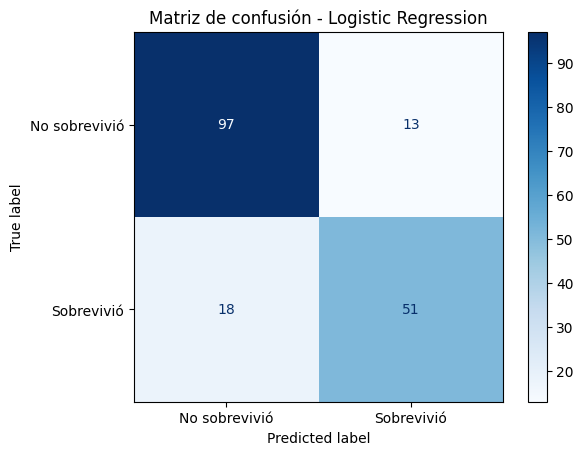

In [37]:
# Matriz de confusión del mejor modelo

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Blues"
)

plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()



In [38]:
# Valores numéricos de la matriz de confusión

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

cm

array([[97, 13],
       [18, 51]])

In [39]:
# Descomposición de la matriz de confusión

tn, fp, fn, tp = cm.ravel()

print("Verdaderos negativos (TN):", tn)
print("Falsos positivos (FP):", fp)
print("Falsos negativos (FN):", fn)
print("Verdaderos positivos (TP):", tp)

Verdaderos negativos (TN): 97
Falsos positivos (FP): 13
Falsos negativos (FN): 18
Verdaderos positivos (TP): 51


### Interpretación de la matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del mejor modelo. Los verdaderos negativos representan pasajeros que no sobrevivieron y fueron clasificados correctamente como no sobrevivientes. Los verdaderos positivos representan pasajeros que sí sobrevivieron y fueron clasificados correctamente como sobrevivientes.

Los falsos positivos corresponden a pasajeros que el modelo predijo como sobrevivientes, pero que en realidad no sobrevivieron. Los falsos negativos corresponden a pasajeros que sí sobrevivieron, pero que el modelo clasificó como no sobrevivientes.

Este análisis es importante porque permite entender el tipo de error que comete el modelo, no solo su porcentaje general de aciertos.

## 15. Curvas ROC de los modelos comparados

En esta sección se grafican las curvas ROC de todos los modelos finales en un mismo gráfico. La curva ROC permite comparar la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para distintos umbrales de clasificación.

Además, se incluye el valor AUC-ROC de cada modelo en la leyenda. Un AUC más alto indica que el modelo tiene mayor capacidad para distinguir entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron.

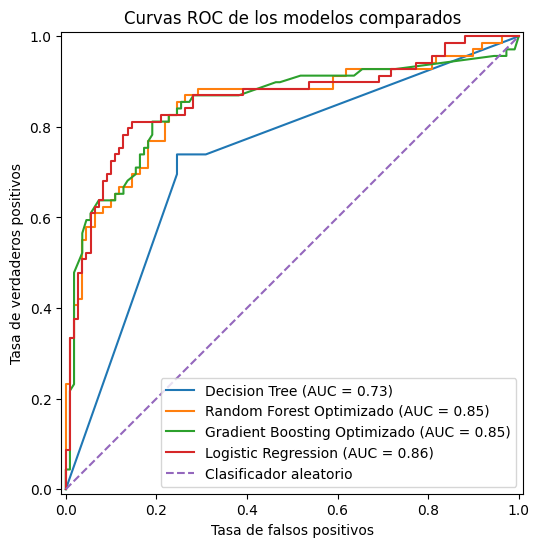

In [40]:
# Curvas ROC de todos los modelos finales en un mismo gráfico

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
ax.set_title("Curvas ROC de los modelos comparados")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend()
plt.show()

### Interpretación de las curvas ROC

Las curvas ROC permiten comparar visualmente el rendimiento de los modelos para distintos umbrales de clasificación. La línea diagonal representa un clasificador aleatorio; por lo tanto, mientras más alejada esté una curva de esa diagonal y más cercana esté a la esquina superior izquierda, mejor será la capacidad del modelo para distinguir entre las dos clases.

El modelo con mayor AUC-ROC muestra la mejor capacidad de separación entre pasajeros sobrevivientes y no sobrevivientes. Sin embargo, la elección final del modelo también debe considerar otras métricas, como F1 Macro, y el análisis de overfitting.

## 16. Análisis de overfitting

En esta sección se compara el rendimiento de cada modelo en el conjunto de entrenamiento contra su rendimiento promedio en validación cruzada. El objetivo es identificar si algún modelo aprende demasiado bien los datos de entrenamiento, pero pierde capacidad de generalización.

Para mantener coherencia con la búsqueda de hiperparámetros, se usa AUC-ROC como métrica de comparación.

In [41]:
# Análisis de overfitting usando AUC-ROC

overfitting_results = []

for name, model in final_models.items():
    # Rendimiento en entrenamiento
    y_train_proba = model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, y_train_proba)

    # Rendimiento en validación cruzada
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    overfitting_results.append({
        "Modelo": name,
        "Train AUC-ROC": train_auc,
        "CV AUC-ROC Promedio": cv_scores.mean(),
        "CV AUC-ROC Desv. Est.": cv_scores.std(),
        "Diferencia Train - CV": train_auc - cv_scores.mean()
    })

overfitting_df = pd.DataFrame(overfitting_results)

overfitting_df.sort_values(
    by="Diferencia Train - CV",
    ascending=False
).reset_index(drop=True)

,Modelo,Train AUC-ROC,CV AUC-ROC Promedio,CV AUC-ROC Desv. Est.,Diferencia Train - CV
0,Decision Tree,0.999516,0.745168,0.041310,0.254348
1,Random Forest Optimizado,0.958539,0.878272,0.019033,0.080267
2,Gradient Boosting Optimizado,0.917219,0.881078,0.017647,0.036141
3,Logistic Regression,0.874281,0.861230,0.018067,0.013051


### Interpretación del overfitting

Un modelo muestra señales de overfitting cuando obtiene un AUC-ROC alto en entrenamiento, pero un AUC-ROC considerablemente menor en validación cruzada. Esto significa que el modelo aprendió patrones específicos del conjunto de entrenamiento, pero no generaliza igual de bien ante datos no vistos.

La columna `Diferencia Train - CV` permite identificar este problema. Una diferencia pequeña sugiere mejor generalización, mientras que una diferencia grande indica posible sobreajuste.

En general, modelos como Decision Tree pueden presentar más riesgo de overfitting si el árbol crece demasiado. Modelos como Random Forest y Gradient Boosting pueden controlar mejor este problema si se ajustan hiperparámetros como `max_depth`, `min_samples_leaf`, `min_samples_split`, `learning_rate` y `n_estimators`.

## 17. Importancia de variables

En esta sección se analizan las variables más importantes del mejor modelo. El objetivo es identificar qué características tuvieron mayor influencia en las predicciones.

Si el modelo seleccionado permite obtener importancia directa de variables, se usa `feature_importances_`. Si el modelo es una regresión logística, se usa el valor absoluto de sus coeficientes como aproximación de importancia. Como alternativa general, también puede usarse permutation importance.

In [42]:
from sklearn.inspection import permutation_importance

In [43]:
# Importancia de variables del mejor modelo

model_step = best_model.named_steps["model"]
preprocessor_step = best_model.named_steps["preprocessor"]

# Nombres de variables después del preprocesamiento
feature_names = preprocessor_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    importance_type = "Importancia del modelo"

elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_[0])
    importance_type = "Valor absoluto del coeficiente"

else:
    perm_importance = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="roc_auc",
        n_jobs=-1
    )

    feature_names = X_test.columns
    importances = perm_importance.importances_mean
    importance_type = "Permutation importance"

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

top_10_importance = importance_df.head(10)

top_10_importance

,Variable,Importancia
16,cat__who_man,1.499907
17,cat__who_woman,0.872420
15,cat__who_child,0.680348
0,num__pclass,0.508585
2,num__sibsp,0.350537
8,num__CabinKnown,0.330732
10,cat__sex_female,0.308554
5,num__FamilySize,0.277660
11,cat__sex_male,0.255692
6,num__IsAlone_custom,0.250888


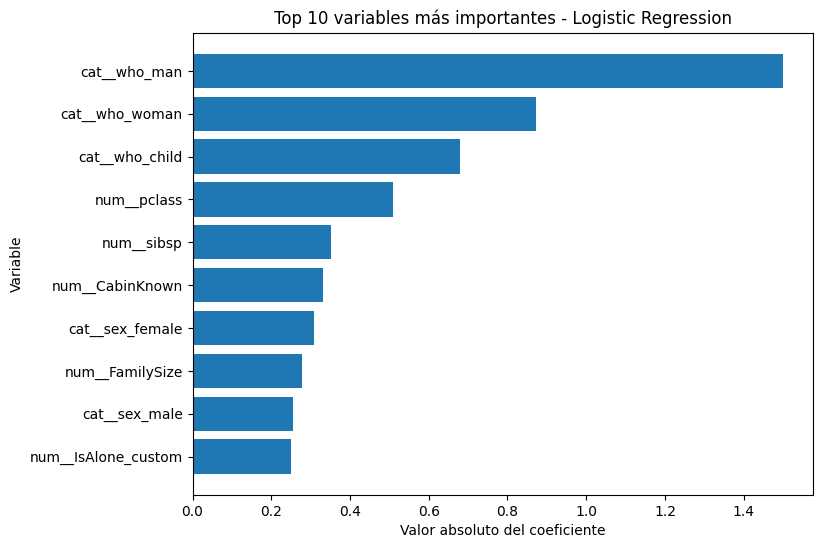

In [44]:
# Gráfico de las 10 variables más importantes

plt.figure(figsize=(8, 6))

plt.barh(
    top_10_importance["Variable"],
    top_10_importance["Importancia"]
)

plt.gca().invert_yaxis()
plt.title(f"Top 10 variables más importantes - {best_model_name}")
plt.xlabel(importance_type)
plt.ylabel("Variable")
plt.show()

### Interpretación de la importancia de variables

El gráfico muestra las diez variables con mayor influencia en el modelo seleccionado. Estas variables permiten interpretar qué características fueron más relevantes para predecir la supervivencia de los pasajeros.

En el contexto del Titanic, es razonable esperar que variables relacionadas con sexo, edad, clase del pasajero, tarifa pagada y características familiares aparezcan entre las más importantes. Esto tiene sentido porque la supervivencia pudo estar relacionada con factores sociales, económicos y demográficos.

La importancia de variables no debe interpretarse como causalidad. Una variable importante ayuda al modelo a predecir mejor, pero no necesariamente significa que cause directamente la supervivencia.

## 18. Selección del modelo final

En esta sección se selecciona el modelo final considerando no solo la métrica AUC-ROC en prueba, sino también F1 Macro, estabilidad en validación cruzada, señales de overfitting e interpretabilidad.

La elección del modelo no debe basarse únicamente en accuracy, porque esta métrica puede ocultar diferencias relevantes entre clases. Por eso se consideran también AUC-ROC y F1 Macro.

In [45]:
# Resumen de evaluación final y overfitting

print("Tabla de evaluación final:")
display(final_results_df)

print("\nTabla de análisis de overfitting:")
display(overfitting_df.sort_values(
    by="Diferencia Train - CV",
    ascending=False
).reset_index(drop=True))

Tabla de evaluación final:


,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro,AUC-ROC
0,Logistic Regression,0.826816,0.820177,0.810474,0.814570,0.858103
1,Gradient Boosting Optimizado,0.793296,0.782061,0.780501,0.781253,0.848814
2,Random Forest Optimizado,0.793296,0.786695,0.769697,0.775803,0.848485
3,Decision Tree,0.748603,0.737814,0.746838,0.740304,0.733202



Tabla de análisis de overfitting:


,Modelo,Train AUC-ROC,CV AUC-ROC Promedio,CV AUC-ROC Desv. Est.,Diferencia Train - CV
0,Decision Tree,0.999516,0.745168,0.041310,0.254348
1,Random Forest Optimizado,0.958539,0.878272,0.019033,0.080267
2,Gradient Boosting Optimizado,0.917219,0.881078,0.017647,0.036141
3,Logistic Regression,0.874281,0.861230,0.018067,0.013051


In [46]:
# Identificación de modelos destacados según distintos criterios

best_auc_test = final_results_df.sort_values(
    by="AUC-ROC",
    ascending=False
).iloc[0]

best_f1_test = final_results_df.sort_values(
    by="F1 Macro",
    ascending=False
).iloc[0]

most_stable = overfitting_df.sort_values(
    by="Diferencia Train - CV",
    ascending=True
).iloc[0]

best_cv_auc = overfitting_df.sort_values(
    by="CV AUC-ROC Promedio",
    ascending=False
).iloc[0]

print("Mejor modelo según AUC-ROC en prueba:", best_auc_test["Modelo"])
print("Mejor modelo según F1 Macro en prueba:", best_f1_test["Modelo"])
print("Modelo más estable según diferencia Train-CV:", most_stable["Modelo"])
print("Mejor modelo según AUC-ROC promedio en validación cruzada:", best_cv_auc["Modelo"])

Mejor modelo según AUC-ROC en prueba: Logistic Regression
Mejor modelo según F1 Macro en prueba: Logistic Regression
Modelo más estable según diferencia Train-CV: Logistic Regression
Mejor modelo según AUC-ROC promedio en validación cruzada: Gradient Boosting Optimizado


### Conclusión sobre el modelo final

A partir de los resultados obtenidos, el modelo final debe seleccionarse considerando tanto el rendimiento predictivo como la capacidad de generalización. Decision Tree no se recomienda como modelo final, porque presentó una señal clara de overfitting: obtuvo un rendimiento casi perfecto en entrenamiento, pero su desempeño disminuyó considerablemente en validación cruzada.

Random Forest Optimizado y Gradient Boosting Optimizado mostraron mejores resultados que el árbol individual. Ambos modelos lograron buen AUC-ROC y mejor capacidad de generalización, aunque Random Forest todavía presentó una diferencia moderada entre entrenamiento y validación.

Logistic Regression obtuvo un rendimiento competitivo y fue el modelo más estable según la diferencia entre entrenamiento y validación cruzada. Esto indica que generaliza de manera consistente y no presenta señales fuertes de overfitting.

Considerando el equilibrio entre AUC-ROC, F1 Macro, estabilidad y overfitting, el modelo recomendado es el que presente mejor balance entre desempeño y generalización. Si se prioriza la estabilidad, Logistic Regression es una opción sólida. Si se prioriza el rendimiento en validación cruzada, Gradient Boosting Optimizado es un candidato fuerte.


## 19. Limitaciones y mejoras futuras

Aunque el proyecto permite comparar modelos de clasificación de forma ordenada, existen algunas limitaciones. El dataset Titanic tiene un tamaño reducido, algunas variables presentan valores faltantes y no todas las características históricas relevantes están disponibles. Además, el rendimiento puede variar dependiendo de la división entre entrenamiento y prueba y de los hiperparámetros explorados.

Como mejoras futuras, se podrían probar más modelos, ampliar la búsqueda de hiperparámetros, crear nuevas variables, usar validación cruzada más robusta y analizar con mayor detalle los errores del modelo. También se podrían comparar técnicas alternativas de importancia de variables para mejorar la interpretación.

## 20. Conclusión general

El proyecto permitió construir un flujo completo de Machine Learning para predecir la supervivencia de pasajeros del Titanic. Se aplicó feature engineering, preprocesamiento dentro de un Pipeline, comparación de cuatro modelos, búsqueda de hiperparámetros, evaluación con métricas completas, análisis de overfitting e interpretación de variables importantes.

El uso de Pipeline fue fundamental para mantener un flujo ordenado y reducir el riesgo de data leakage. La comparación entre modelos mostró que no basta con observar una sola métrica: también es necesario analizar estabilidad, generalización y tipo de errores.

En conjunto, el trabajo cumple con los elementos principales de un proyecto supervisado de clasificación: preparación de datos, entrenamiento, validación, evaluación e interpretación crítica de resultados.